In [12]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


Load data

In [13]:
df = pd.read_csv("Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

print(df.shape)
print(df.head())
print(df.dtypes)

(7500, 16)
  transaction_id user_id  age gender  daily_screen_time_hours  \
0       TXN00001  U00001   21   Male                     3.23   
1       TXN00002  U00002   24  Other                     5.09   
2       TXN00003  U00003   31  Other                     6.06   
3       TXN00004  U00004   32  Other                     7.83   
4       TXN00005  U00005   25   Male                     9.96   

   social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
0                2.01          0.89              4.55         7.55   
1                3.81          2.24              4.44         7.66   
2                1.36          3.83              2.35         4.92   
3                5.85          1.51              3.54         8.23   
4                5.92          3.42              5.27         6.21   

   notifications_per_day  app_opens_per_day  weekend_screen_time stress_level  \
0                    248                154                 3.95       Medium   
1              

Data Cleaning

In [14]:
#---Check for nulls---
print(df.isnull().sum)

<bound method DataFrame.sum of       transaction_id  user_id    age  gender  daily_screen_time_hours  \
0              False    False  False   False                    False   
1              False    False  False   False                    False   
2              False    False  False   False                    False   
3              False    False  False   False                    False   
4              False    False  False   False                    False   
...              ...      ...    ...     ...                      ...   
7495           False    False  False   False                    False   
7496           False    False  False   False                    False   
7497           False    False  False   False                    False   
7498           False    False  False   False                    False   
7499           False    False  False   False                    False   

      social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
0                  

In [15]:
# Fill in nulls in addiction_level with "not classified"
df["addiction_level"] = df["addiction_level"].fillna("Not Classified")

#Confirm no more nulls
print(df.isnull().sum)

<bound method DataFrame.sum of       transaction_id  user_id    age  gender  daily_screen_time_hours  \
0              False    False  False   False                    False   
1              False    False  False   False                    False   
2              False    False  False   False                    False   
3              False    False  False   False                    False   
4              False    False  False   False                    False   
...              ...      ...    ...     ...                      ...   
7495           False    False  False   False                    False   
7496           False    False  False   False                    False   
7497           False    False  False   False                    False   
7498           False    False  False   False                    False   
7499           False    False  False   False                    False   

      social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
0                  

In [16]:
# Check for duplicates
print("Duplicates", df.duplicated().sum)

Duplicates <bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
7495    False
7496    False
7497    False
7498    False
7499    False
Length: 7500, dtype: bool>


In [17]:
# Age range should 18-35
print(df["age"].describe())

#Screen time sholdnt be negative
print(df[df["daily_screen_time_hours"]<0])

count    7500.000000
mean       26.568800
std         5.197108
min        18.000000
25%        22.000000
50%        27.000000
75%        31.000000
max        35.000000
Name: age, dtype: float64
Empty DataFrame
Columns: [transaction_id, user_id, age, gender, daily_screen_time_hours, social_media_hours, gaming_hours, work_study_hours, sleep_hours, notifications_per_day, app_opens_per_day, weekend_screen_time, stress_level, academic_work_impact, addiction_level, addicted_label]
Index: []


Exploratory Data Analysis

In [18]:
# --- Descriptive Stats --
numeric_cols =[
    "age","daily_screen_time_hours","social_media_hours","gaming_hours","work_study_hours","sleep_hours","notifications_per_day","app_opens_per_day","weekend_screen_time"
]

print(df[numeric_cols].describe().round(2))

           age  daily_screen_time_hours  social_media_hours  gaming_hours  \
count  7500.00                  7500.00             7500.00       7500.00   
mean     26.57                     7.50                3.27          2.01   
std       5.20                     2.61                1.59          1.15   
min      18.00                     3.00                0.50          0.00   
25%      22.00                     5.22                1.91          1.02   
50%      27.00                     7.52                3.27          2.04   
75%      31.00                     9.81                4.63          2.99   
max      35.00                    12.00                6.00          4.00   

       work_study_hours  sleep_hours  notifications_per_day  \
count           7500.00      7500.00                7500.00   
mean               3.24         6.74                 134.26   
std                1.60         1.28                  66.59   
min                0.50         4.50                  

In [19]:
#--- categorical breakdowns --
for col in ["gender","stress_level","academic_work_impact","addiction_level"]:
    print(f"\n{col}:")
    print(df[col].value_counts())



gender:
gender
Male      2553
Other     2486
Female    2461
Name: count, dtype: int64

stress_level:
stress_level
High      2560
Low       2503
Medium    2437
Name: count, dtype: int64

academic_work_impact:
academic_work_impact
No     3753
Yes    3747
Name: count, dtype: int64

addiction_level:
addiction_level
Moderate          2874
Severe            2434
Mild              1373
Not Classified     819
Name: count, dtype: int64


In [20]:
# --- How many addicted vs not addicted ---
print(df["addicted_label"].value_counts())
print(df["addicted_label"].value_counts(normalize=True).mul(100).round(1))

addicted_label
1    5308
0    2192
Name: count, dtype: int64
addicted_label
1    70.8
0    29.2
Name: proportion, dtype: float64


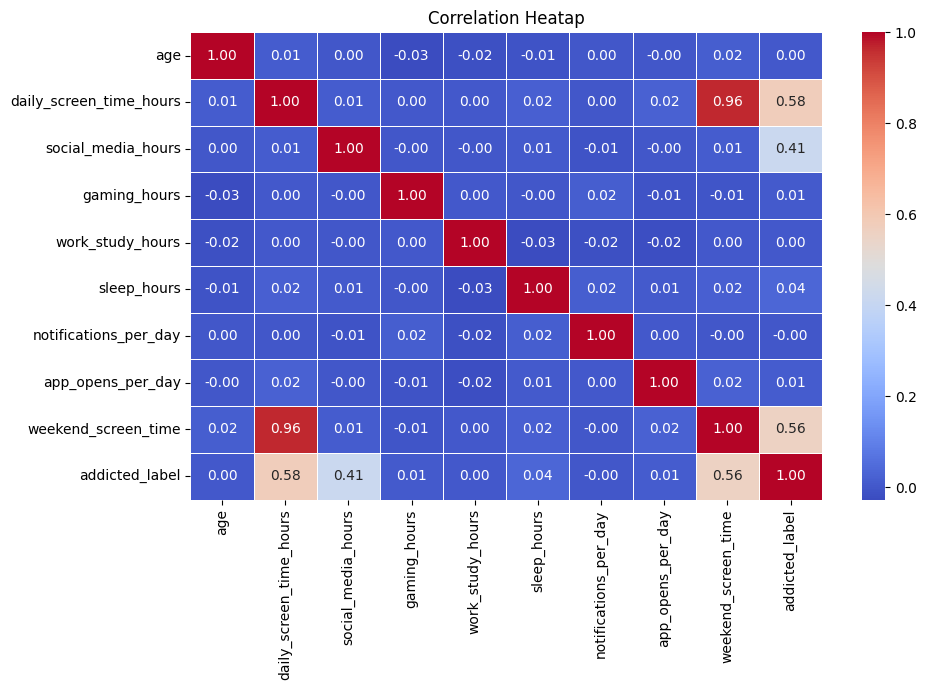

In [21]:
#--- Correlation matrix ---
plt.figure(figsize=(10,7))
corr = df[numeric_cols +["addicted_label"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f",cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatap")
plt.tight_layout()
plt.show()


Visualisations

Screen Time Distribution graph

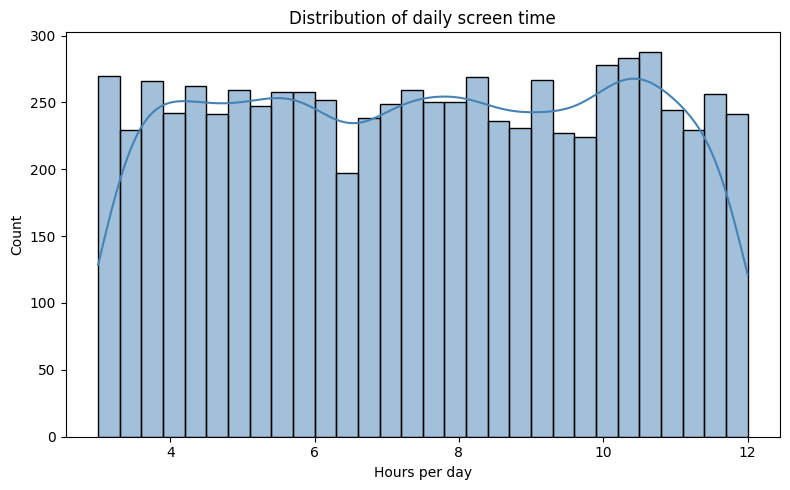

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df["daily_screen_time_hours"], bins=30, kde=True,color="steelblue")
plt.title("Distribution of daily screen time")
plt.xlabel("Hours per day")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Addiction level breakdown

C:\Users\ifeany school\AppData\Local\Temp\ipykernel_12484\3863269315.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x="addiction_level", order=order, palette="Reds")


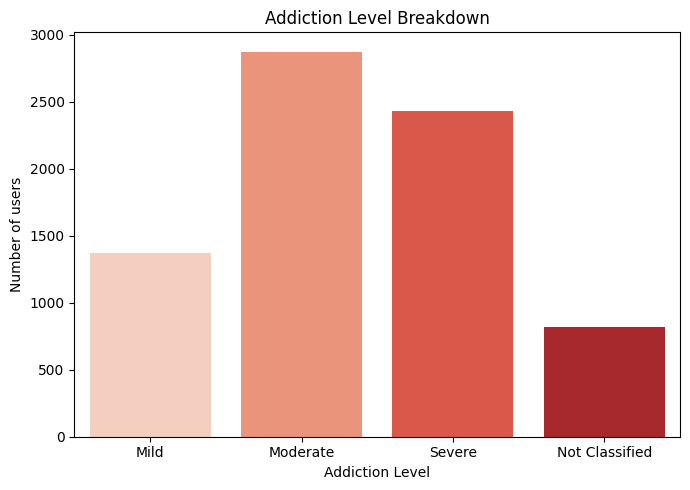

In [28]:
order = ["Mild", "Moderate", "Severe", "Not Classified"]
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="addiction_level", order=order, palette="Reds")
plt.title("Addiction Level Breakdown")
plt.xlabel("Addiction Level")
plt.ylabel("Number of users")
plt.tight_layout()
plt.show()

Screen Time by Addiction Level

C:\Users\ifeany school\AppData\Local\Temp\ipykernel_12484\3683251827.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="addiction_level", y=("daily_screen_time_hours"), order=order, palette="Reds")


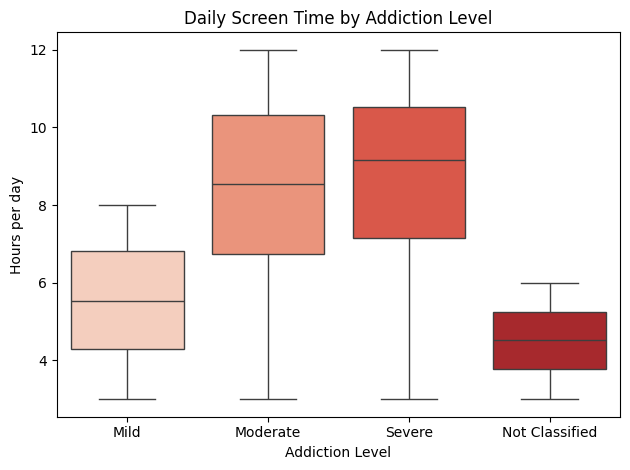

In [29]:
plt.Figure(figsize=(8,5))
sns.boxplot(data=df, x="addiction_level", y=("daily_screen_time_hours"), order=order, palette="Reds")
plt.title("Daily Screen Time by Addiction Level")
plt.xlabel("Addiction Level")
plt.ylabel("Hours per day")
plt.tight_layout()
plt.show()

Social Media Hours by Addictiction level

C:\Users\ifeany school\AppData\Local\Temp\ipykernel_12484\2305386910.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="addiction_level", y="social_media_hours", order=order, palette="Blues")


<function matplotlib.pyplot.show(close=None, block=None)>

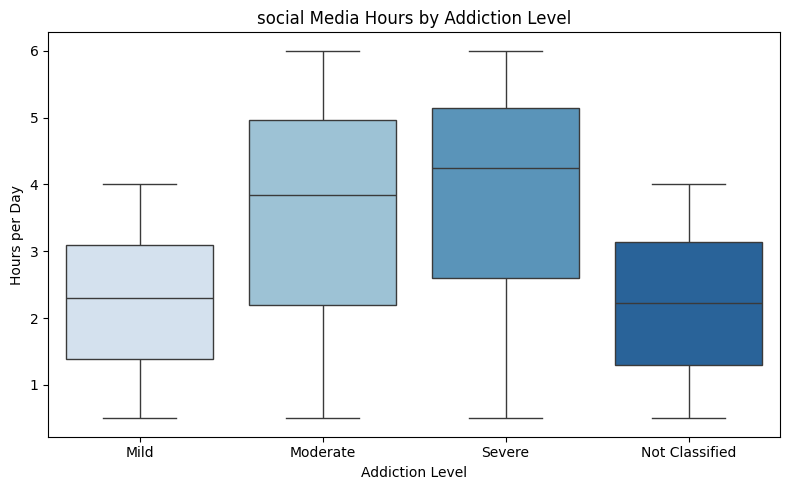

In [32]:
order = ["Mild", "Moderate", "Severe", "Not Classified"]

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="addiction_level", y="social_media_hours", order=order, palette="Blues")
plt.title("social Media Hours by Addiction Level")
plt.xlabel("Addiction Level")
plt.ylabel("Hours per Day")
plt.tight_layout()
plt.show

Sleep Hours by Addiction Level

C:\Users\ifeany school\AppData\Local\Temp\ipykernel_12484\2038225513.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="addiction_level", y="sleep_hours", order=order, palette="Purples")


<function matplotlib.pyplot.show(close=None, block=None)>

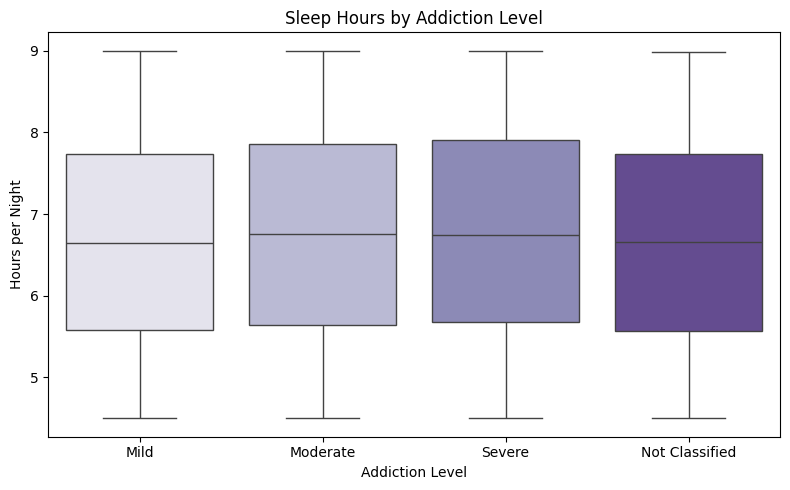

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="addiction_level", y="sleep_hours", order=order, palette="Purples")
plt.title("Sleep Hours by Addiction Level")
plt.xlabel("Addiction Level")
plt.ylabel("Hours per Night")
plt.tight_layout()
plt.show

Stress Level By Addiction Level

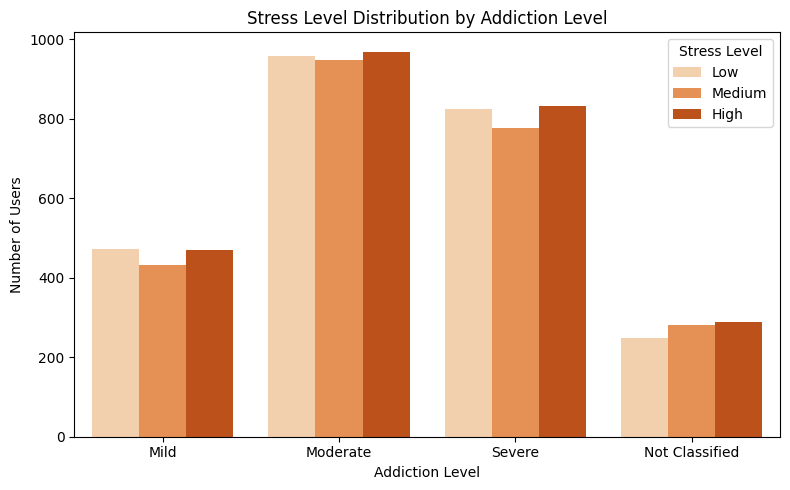

In [34]:
plt.figure(figsize=(8,5))
stress_order= ["Low", "Medium", "High"]
addiction_order= ["Mild", "Moderate", "Severe", "Not Classified"]

stress_ct= df.groupby(["addiction_level", "stress_level"]).size().reset_index(name="count")

sns.barplot(data=stress_ct, x="addiction_level", y="count", hue="stress_level", order=addiction_order, hue_order=stress_order, palette="Oranges")
plt.title("Stress Level Distribution by Addiction Level")
plt.xlabel("Addiction Level")
plt.ylabel("Number of Users")
plt.legend(title="Stress Level")
plt.tight_layout()
plt.show()


Screen Time vs Social Media

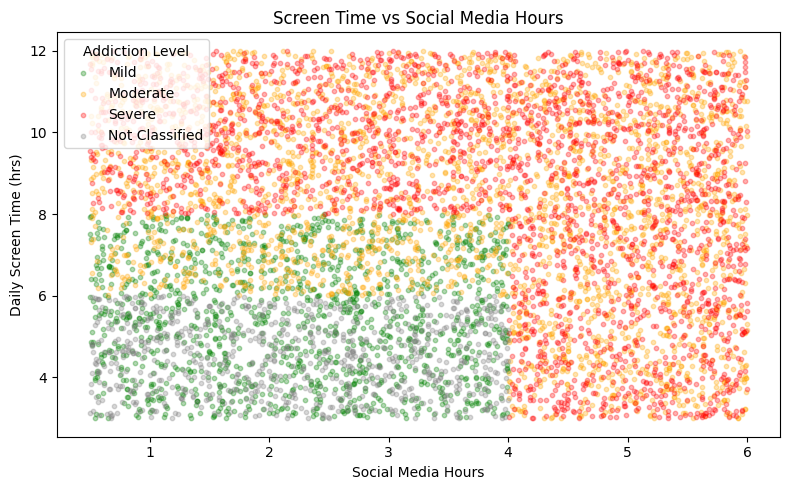

In [36]:
plt.figure(figsize=(8,5))
colors= {"Mild": "green", "Moderate": "orange", "Severe": "red", "Not Classified":"grey"}

for level in addiction_order:
    subset= df[df["addiction_level"]==level]
    plt.scatter(subset["social_media_hours"],subset["daily_screen_time_hours"], alpha=0.3, s=10, label=level, color=colors[level])


plt.title("Screen Time vs Social Media Hours")
plt.xlabel("Social Media Hours")
plt.ylabel("Daily Screen Time (hrs)")
plt.legend(title="Addiction Level")
plt.tight_layout()
plt.show()